## functions 

In [5]:
import math
from scipy import signal

class BiquadDF2T:
    """Direct Form II Transposed biquad: y = b0*x + z1; z1 = b1*x - a1*y + z2; z2 = b2*x - a2*y"""
    __slots__ = ("b0","b1","b2","a1","a2","z1","z2")
    def __init__(self, b0,b1,b2,a1,a2):
        self.b0 = float(b0); self.b1 = float(b1); self.b2 = float(b2)
        self.a1 = float(a1); self.a2 = float(a2)
        self.z1 = 0.0; self.z2 = 0.0

    def process(self, x: float) -> float:
        y = self.b0*x + self.z1
        self.z1 = self.b1*x - self.a1*y + self.z2
        self.z2 = self.b2*x - self.a2*y
        return y

class Cascade:
    __slots__ = ("sections",)
    def __init__(self, sections):
        self.sections = sections  # list[BiquadDF2T]

    def process(self, x: float) -> float:
        for s in self.sections:
            x = s.process(x)
        return x
    

def make_cascade_from_sos(sos):
    secs = []
    for (b0,b1,b2,a0,a1,a2) in sos:
        # assumiamo a0=1
        secs.append(BiquadDF2T(b0,b1,b2,a1,a2))
    return Cascade(secs)

def notch_sos(f0, Q, fs):
    b, a = signal.iirnotch(f0, Q=Q, fs=fs)
    return signal.tf2sos(b, a)

In [ ]:
import numpy as np
import csv

fs = 2000.0
NUM_CHANNELS = 6

# Bandpass 20-450 (Butterworth 4th order -> 2 biquad SOS)
sos_bp = signal.butter(4, [20, 450], btype='bandpass', fs=fs, output='sos')

# Notch 50, 100, 150
Q = 25 # 20 - 50; lower -> broader; higher -> narrower
sos_notch_50  = notch_sos(50,  Q, fs)
sos_notch_100 = notch_sos(100, Q, fs)
sos_notch_150 = notch_sos(150, Q, fs)

# Notch cascata (stack delle SOS)
sos_notch = np.vstack([sos_notch_50, sos_notch_100, sos_notch_150])

# Envelope LPF 10 Hz - Butterworth 2nd order -> 1 biquad
sos_env = signal.butter(2, 10, btype='lowpass', fs=fs, output='sos')

print("sos_bp=\n", sos_bp)
print("sos_notch=\n", sos_notch)
print("sos_env=\n", sos_env)


# Filtri per canale (stato separato!)
global emg_bp_filters, emg_notch_filters, env_lp_filters
emg_bp_filters = [make_cascade_from_sos(sos_bp) for _ in range(NUM_CHANNELS)]
emg_notch_filters = [make_cascade_from_sos(sos_notch) for _ in range(NUM_CHANNELS)]
env_lp_filters = [make_cascade_from_sos(sos_env) for _ in range(NUM_CHANNELS)]

# save coeffs in a file
np.savetxt("sos_bp.csv", sos_bp, delimiter=",")
np.savetxt("sos_notch.csv", sos_notch, delimiter=",")
np.savetxt("sos_env.csv", sos_env, delimiter=",")

sos_bp=
 [[ 0.05851271  0.11702542  0.05851271  1.         -0.23229445  0.05846329]
 [ 1.          2.          1.          1.         -0.24489098  0.47739693]
 [ 1.         -2.          1.          1.         -1.8805833   0.8848214 ]
 [ 1.         -2.          1.          1.         -1.95160019  0.95553351]]
sos_notch=
 [[ 0.99686824 -1.96919027  0.99686824  1.         -1.96919027  0.99373647]
 [ 0.99375596 -1.89023617  0.99375596  1.         -1.89023617  0.98751193]
 [ 0.99066295 -1.76537429  0.99066295  1.         -1.76537429  0.98132589]]
sos_env=
 [[ 6.10061788e-05  1.22012358e-04  6.10061788e-05  1.00000000e+00
  -1.97778648e+00  9.78030508e-01]]


# inspect filters

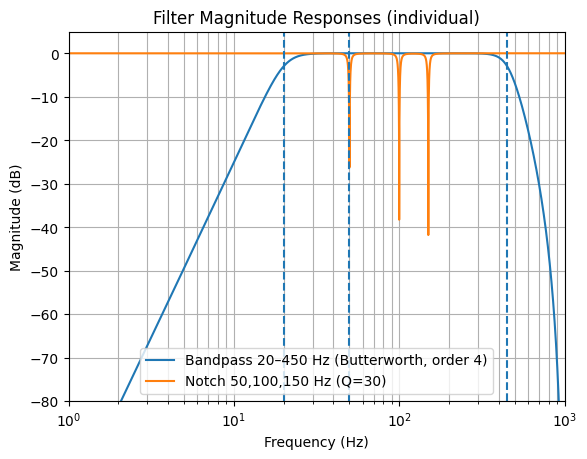

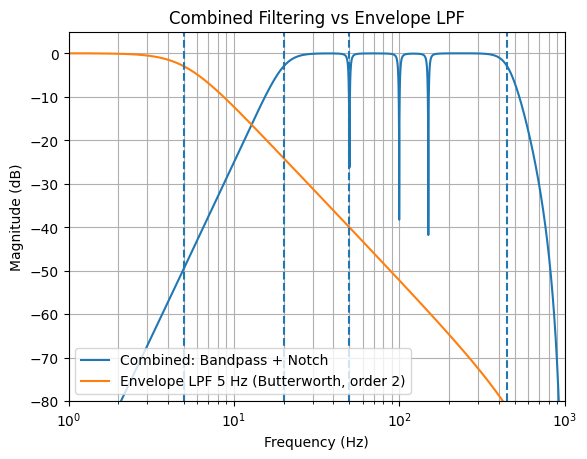

In [7]:

import matplotlib.pyplot as plt


def sos_mag_db(sos, fs, worN=8192):
    f, h = signal.sosfreqz(sos, worN=worN, fs=fs)  # f in Hz
    mag_db = 20*np.log10(np.maximum(np.abs(h), 1e-12))
    return f, mag_db

# --- plot 1: risposte individuali ---
f_bp, mag_bp = sos_mag_db(sos_bp, fs)
f_notch, mag_notch = sos_mag_db(sos_notch, fs)

plt.figure()
plt.semilogx(f_bp, mag_bp, label='Bandpass 20–450 Hz (Butterworth, order 4)')
plt.semilogx(f_notch, mag_notch, label='Notch 50,100,150 Hz (Q=30)')
plt.axvline(20, linestyle='--')
plt.axvline(450, linestyle='--')
plt.axvline(50, linestyle='--')
plt.xlim(1, fs/2)
plt.ylim(-80, 5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('Filter Magnitude Responses (individual)')
plt.grid(True, which='both')
plt.legend()

# --- plot 2: cascata bandpass+notch, e envelope LP ---
sos_combined = np.vstack([sos_bp, sos_notch])  # cascata SOS = stack righe

f_c, mag_c = sos_mag_db(sos_combined, fs)
f_env, mag_env = sos_mag_db(sos_env, fs)

plt.figure()
plt.semilogx(f_c, mag_c, label='Combined: Bandpass + Notch')
plt.semilogx(f_env, mag_env, label='Envelope LPF 5 Hz (Butterworth, order 2)')
plt.axvline(5, linestyle='--')
plt.axvline(50, linestyle='--')
plt.axvline(20, linestyle='--')
plt.axvline(450, linestyle='--')
plt.xlim(1, fs/2)
plt.ylim(-80, 5)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.title('Combined Filtering vs Envelope LPF')
plt.grid(True, which='both')
plt.legend()

plt.show()